# End-to-end marketplace matching and allocation

This notebook follows multiple job descriptions through the complete system:

**raw JDs → structured jobs → embeddings → retrieval → performance scoring → global allocation**

The offline demo deliberately uses similar jobs so they compete for the same candidates. Set `USE_LIVE_JDS = True` to replace them with the raw descriptions below.

In [1]:
from pathlib import Path
import os, sys

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parents[1]
for source in [
    ROOT / 'matching-pipeline/retrieval/src',
    ROOT / 'matching-pipeline/modeling/src',
    ROOT / 'matching-pipeline/allocation/src',
]:
    sys.path.insert(0, str(source))

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv

from allocation.optimizer import greedy_allocate, optimize_allocation
from allocation.scenarios import has_required_certifications, select_similar_jobs
from modeling.reranker import rerank_candidates
from retrieval.embeddings import embedding_matrix
from retrieval.exact_search import exact_cosine_search
from retrieval.job_extraction import extract_job_profiles
from retrieval.renderers import render_job

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_colwidth', 70)

Matplotlib is building the font cache; this may take a moment.


## 1. Choose the job descriptions

Offline mode uses ten similar jobs already in the project, so the full notebook is reproducible and free to run. Live mode sends each pasted JD to the extraction model and embedding model.

In [2]:
USE_LIVE_JDS = False
DEMO_JOB_COUNT = 10
RETRIEVE_K = 50

JOB_DESCRIPTIONS = [
    '''Senior Machine Learning Engineer. Build production ranking and recommendation
    systems using Python, PyTorch, SQL, AWS, and Kubernetes. 5+ years required.''',
    '''Machine Learning Platform Engineer. Own model deployment, feature pipelines,
    monitoring, Python services, Docker, Kubernetes, and cloud infrastructure.''',
    '''Applied ML Engineer. Develop NLP models and retrieval systems, evaluate model
    quality, and ship Python-based services with data and product teams.''',
]

DATA = ROOT / 'ground-truth-generation/data/v1'
EMBEDDINGS = ROOT / 'matching-pipeline/retrieval/artifacts/embeddings'
MODEL_PATH = ROOT / 'matching-pipeline/modeling/artifacts/model/performance_model.joblib'
jobs = pd.read_parquet(DATA / 'jobs.parquet')
candidates = pd.read_parquet(DATA / 'candidates.parquet')
assessments = pd.read_parquet(DATA / 'candidate_assessments.parquet')
candidate_embeddings = pd.read_parquet(EMBEDDINGS / 'candidates.parquet').sort_values('entity_id').reset_index(drop=True)
stored_job_embeddings = pd.read_parquet(EMBEDDINGS / 'jobs.parquet')
model = joblib.load(MODEL_PATH)

## 2. Structure and embed the JDs

The model needs explicit fields such as skills, seniority, experience, and certifications. The same structured representation is also rendered into text for embedding.

In [3]:
if USE_LIVE_JDS:
    from openai import OpenAI
    load_dotenv(ROOT / '.env')
    if not os.getenv('OPENAI_API_KEY'):
        raise RuntimeError('OPENAI_API_KEY is required for live JD mode')
    client = OpenAI(timeout=60.0, max_retries=3)
    role_options = (jobs[['role_family', 'role_type', 'role_track']]
                    .drop_duplicates().to_dict('records'))
    profiles = extract_job_profiles(
        JOB_DESCRIPTIONS, role_options, client,
        model=os.getenv('OPENAI_EXTRACTION_MODEL', 'gpt-5.6-luna'),
    )
    selected_jobs = pd.DataFrame([profile.model_dump() for profile in profiles])
    response = client.embeddings.create(
        model=os.getenv('OPENAI_EMBEDDING_MODEL', 'text-embedding-3-small'),
        dimensions=int(candidate_embeddings.dimensions.iloc[0]),
        input=[render_job(profile) for profile in profiles],
    )
    job_matrix = np.asarray([item.embedding for item in response.data], dtype=np.float32)
else:
    selected_jobs = select_similar_jobs(jobs, stored_job_embeddings, DEMO_JOB_COUNT)
    vector_lookup = stored_job_embeddings.set_index('entity_id').embedding
    job_matrix = np.stack(selected_jobs.job_id.map(vector_lookup).map(
        lambda value: np.asarray(value, dtype=np.float32)))

selected_jobs[['job_id', 'title', 'seniority', 'minimum_years_experience',
               'required_skills', 'required_certifications']]

,job_id,title,seniority,minimum_years_experience,required_skills,required_certifications
0,3884426762,PRN Registered Nurse,senior,NaN,[infection prevention],[]
1,3901937580,Registered Nurse I (Nights),senior,2.0,[infection prevention],[]
2,3891074610,Team Nurse - Agency Only,senior,NaN,[],[]
3,3905261467,Licensed Practical Nurse - Primary Care PACT - UP TO 10k SIGN ON B...,senior,5.0,[medication administration],[BLS certification]
4,3889279489,Licensed Practical Nurse (LPN),senior,NaN,[medication administration],[]
5,3904719931,"Assistant Nurse Manager, Day Shift, Rehabilitation",senior,3.0,[],[BLS certification]
6,3902358712,Nurse (SANE) - Outpatient,senior,NaN,[],[]
7,3900955065,REGISTERED NURSE - **La Selva Residential**,senior,15.0,[],[]
8,3889290143,Certified Registered Nurse Practitioner - Warren State Hospital,senior,NaN,[],[]
9,3903843291,"Registered Nurse (RN), Night Shift, Acute-Care Rehab",senior,3.0,[],[BLS certification]


### Are these jobs actually similar?

The heatmap shows cosine similarity between JD embeddings. Darker cells mean the jobs describe more similar work—and are therefore more likely to compete for candidates.

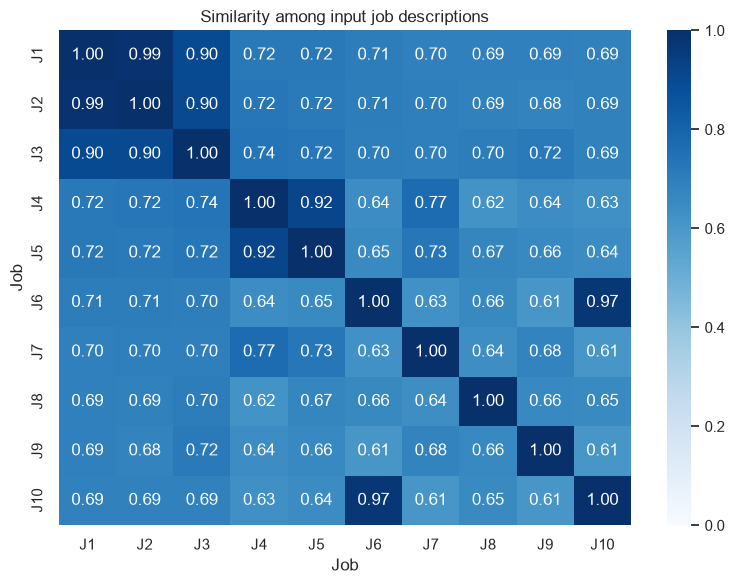

In [4]:
normalized_jobs = job_matrix / np.linalg.norm(job_matrix, axis=1, keepdims=True)
job_similarity = normalized_jobs @ normalized_jobs.T
job_labels = [f'J{i+1}' for i in range(len(selected_jobs))]
plt.figure(figsize=(8, 6))
sns.heatmap(job_similarity, xticklabels=job_labels, yticklabels=job_labels,
            cmap='Blues', vmin=0, vmax=1, annot=True, fmt='.2f')
plt.title('Similarity among input job descriptions')
plt.xlabel('Job'); plt.ylabel('Job'); plt.tight_layout();

## 3. Retrieve candidates

Vector search narrows 5,000 candidates to 50 plausible candidates per job. This notebook uses exact cosine search for reproducibility; production can swap in the existing HNSW store without changing later stages.

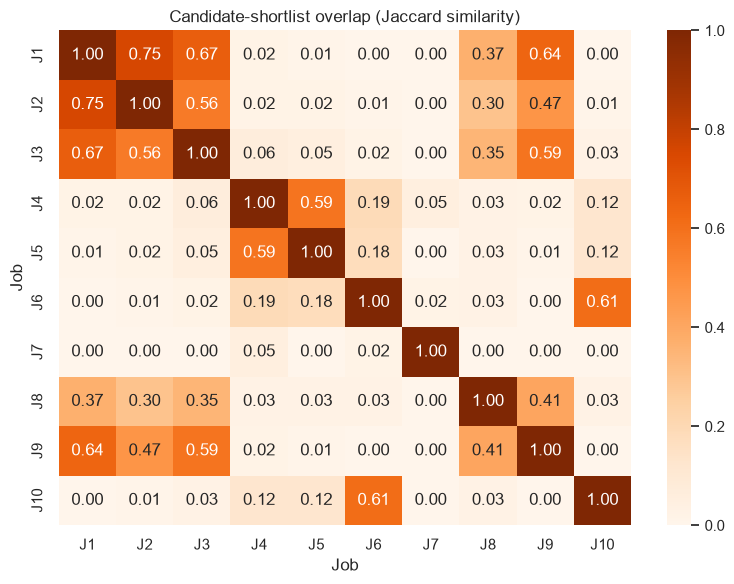

In [5]:
candidate_matrix = embedding_matrix(candidate_embeddings)
retrieved_indices, retrieved_scores = exact_cosine_search(job_matrix, candidate_matrix, RETRIEVE_K)
retrievals = {}
for row, job_id in enumerate(selected_jobs.job_id):
    retrievals[job_id] = pd.DataFrame({
        'candidate_id': candidate_embeddings.iloc[retrieved_indices[row]].entity_id.to_numpy(),
        'retrieval_rank': np.arange(1, RETRIEVE_K + 1),
        'embedding_similarity': retrieved_scores[row],
    })

overlap = np.eye(len(selected_jobs))
for i, first_job in enumerate(selected_jobs.job_id):
    first = set(retrievals[first_job].candidate_id)
    for j, second_job in enumerate(selected_jobs.job_id):
        second = set(retrievals[second_job].candidate_id)
        overlap[i, j] = len(first & second) / len(first | second)
plt.figure(figsize=(8, 6))
sns.heatmap(overlap, xticklabels=job_labels, yticklabels=job_labels,
            cmap='Oranges', vmin=0, vmax=1, annot=True, fmt='.2f')
plt.title('Candidate-shortlist overlap (Jaccard similarity)')
plt.xlabel('Job'); plt.ylabel('Job'); plt.tight_layout();

## 4. Predict performance for every retrieved pair

LightGBM now replaces retrieval order with predicted success probability. Required certifications remain a hard eligibility rule rather than a soft preference.

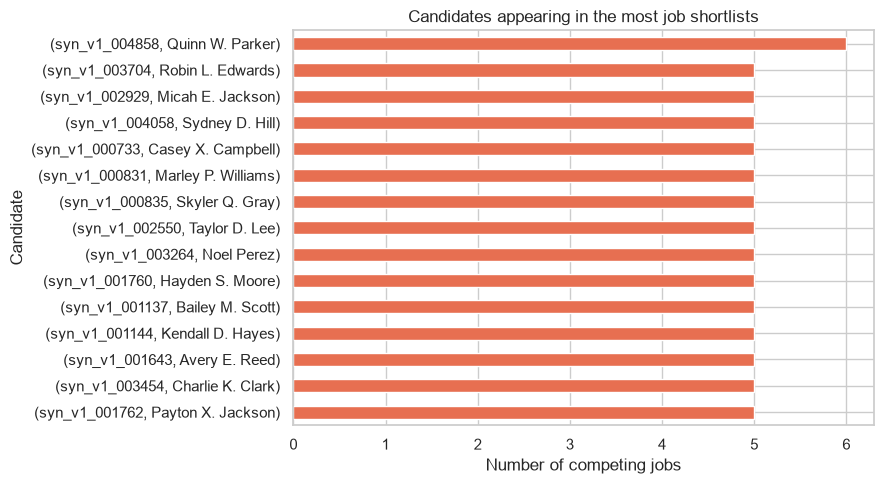

In [6]:
certifications = candidates.set_index('candidate_id').certifications
pair_frames = []
for job in selected_jobs.itertuples(index=False):
    scored = rerank_candidates(
        pd.Series(job._asdict()), retrievals[job.job_id], candidates, assessments,
        model, top_k=RETRIEVE_K,
    )
    scored['eligible'] = scored.candidate_id.map(
        lambda candidate_id: has_required_certifications(
            certifications.loc[candidate_id], job.required_certifications))
    scored.insert(0, 'job_id', job.job_id)
    scored.insert(1, 'job_title', job.title)
    pair_frames.append(scored)
pairs = pd.concat(pair_frames, ignore_index=True)

competition = (pairs.loc[pairs.eligible].groupby(['candidate_id', 'name'])
               .job_id.nunique().sort_values(ascending=False).head(15))
ax = competition.sort_values().plot.barh(figsize=(9, 5), color='#e76f51')
ax.set(title='Candidates appearing in the most job shortlists',
       xlabel='Number of competing jobs', ylabel='Candidate')
plt.tight_layout();

## 5. Compare greedy and globally optimal allocation

Greedy processes jobs one at a time. The binary linear program sees all jobs together and first maximizes the number of filled jobs, then the sum of predicted success probabilities at that fill count. A job may remain unfilled when qualified candidates are unavailable; each candidate can receive at most one assignment.

In [ ]:
greedy = greedy_allocate(pairs, require_all=False)
optimal = optimize_allocation(pairs)
greedy_total = greedy.performance_probability.sum()
optimal_total = optimal.performance_probability.sum()
comparison = pd.DataFrame({
    'method': ['Job-by-job greedy', 'Global linear optimization'],
    'expected successful assignments': [greedy_total, optimal_total],
})
ax = sns.barplot(comparison, x='method', y='expected successful assignments',
                 hue='method', palette=['#8ecae6', '#2a9d8f'], legend=False)
ax.bar_label(ax.containers[0], fmt='%.3f', padding=3)
ax.set(title=f'Global optimization gain: {optimal_total-greedy_total:.3f}', xlabel='', ylabel='Sum of success probabilities')
plt.tight_layout();
comparison

### Which assignments changed?

These are the jobs where the optimizer accepted a small loss on one job to unlock a larger gain elsewhere.

In [8]:
assignment_comparison = greedy[[
    'job_id', 'job_title', 'candidate_id', 'name', 'performance_probability'
]].merge(optimal[[
    'job_id', 'candidate_id', 'name', 'performance_probability'
]], on='job_id', suffixes=('_greedy', '_optimal'))
changed = assignment_comparison.loc[
    assignment_comparison.candidate_id_greedy != assignment_comparison.candidate_id_optimal
].copy()
changed['probability_change'] = (changed.performance_probability_optimal -
                                 changed.performance_probability_greedy)
changed[['job_title', 'name_greedy', 'performance_probability_greedy',
         'name_optimal', 'performance_probability_optimal', 'probability_change']]

,job_title,name_greedy,performance_probability_greedy,name_optimal,performance_probability_optimal,probability_change
7,"Registered Nurse (RN), Night Shift, Acute-Care Rehab",Quinn T. Hill,0.696273,Sage N. Collins,0.641207,-0.055066
8,"Assistant Nurse Manager, Day Shift, Rehabilitation",Sage N. Collins,0.640680,Quinn T. Hill,0.710405,0.069725


## 6. Final allocation

These scores can now pass to a production allocation or review system. They are predicted probabilities—not guarantees—and should remain visible to the decision maker.

In [ ]:
final_allocation = optimal[[
    'job_id', 'job_title', 'candidate_id', 'name', 'current_title',
    'retrieval_rank', 'embedding_similarity', 'performance_probability'
]].sort_values('job_title').reset_index(drop=True)
assert final_allocation.job_id.nunique() == len(final_allocation)
assert final_allocation.candidate_id.nunique() == len(final_allocation)
print(f'Filled {len(final_allocation)}/{len(selected_jobs)} jobs')
final_allocation.style.format({
    'embedding_similarity': '{:.3f}',
    'performance_probability': '{:.1%}',
})